# Figures 

In [1]:
%reload_ext autoreload
%autoreload 2

from tes.data_ingestion import DataRead

from tes.analysis import AnalysisFunc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.colors import TwoSlopeNorm
from matplotlib.patches import Patch
from pathlib import Path
import glob
import statistics
import networkx as nx
import seaborn as sns
import matplotlib.colors as mcolors
from tes.DataUtils import DataUtils

In [2]:
analyse = AnalysisFunc()
reader = DataRead()
utils = DataUtils()

../../data/connectivity_matrix/mb_communities.npz already exists
DataUtils initialized


### Figure: Convey Hypothesis

- Coverage
- Propagation speed
- Likelihood
- Duration

## Figure: Structural measures effect on parameters 
- Take all nodes you have data for

#### Data folders (Containing global order, local order and node community data)
- raw/(BLA,PERI,ENTI, ORBI, RE, PIR)
- raw/check_connector
- raw/check_control

#### Data folders (containing global order and local order)
- raw/random (contains betweeness centrality data)
- raw/random_nodes
- results/processed (only global order is correct for 1000 iterations)

### Compute data for figure 2 
- Read data of all the nodes from respective folders
- Find betweenness centrality, degree, nodal efficiency and eigen vector centrality for above nodes


### Nodes

In [3]:
control_node = [251, 38, 71, 284, 1, 214, 149, 362]
control_name = ["MOB", "LSc", "MOp", "MRN"]
connector_node = [214, 1, 215, 2, 249, 36, 137, 350, 53, 266]
connector_name = ["MOp", "MOs", "PERI", "LHA", "ENTI"]
imp_nodes = [36, 249, 53, 266, 23, 236, 113, 326, 64, 277, 43, 256]
imp_name = ["PERI", "ENTI", "ORB", "RE", "BLA", "PIR"]

nodes = [
    36,
    249,
    53,
    266,
    23,
    236,
    113,
    326,
    64,
    277,
    43,
    256,
    214,
    1,
    215,
    2,
    137,
    350,
    251,
    38,
    71,
    284,
    149,
    362,
]
node_label = [
    "PERI",
    "ENTI",
    "ORB",
    "RE",
    "BLA",
    "PIR",
    "MOp",
    "MOs",
    "LHA",
    "MOB",
    "LSc",
    "MRN",
]

#### Calculate 
- Betweenness centrality
- Nodal Efficiency
- Degree
- Eigen vector centrality

In [4]:
G = nx.from_numpy_array(utils.WHOLE_BRAIN_CONN)
bet_cent = nx.betweenness_centrality(G)
deg_cent = nx.degree_centrality(G)
eig_cent = nx.eigenvector_centrality(G)
efficiency = {}
for node in G.nodes:
    # Calculate the sum of reciprocal of shortest path lengths from the node to all other nodes
    sp_lengths = nx.shortest_path_length(G, source=node)
    sum_reciprocal_sp = sum(1 / length for length in sp_lengths.values() if length > 0)

    # Calculate efficiency: E(v) = (1 / (N-1)) * sum(1 / d(v, u))
    # where N is the number of nodes and d(v, u) is the shortest path length between v and u
    efficiency[node] = sum_reciprocal_sp / (len(G.nodes) - 1)


bc_vals = []
deg_vals = []
ev_vals = []
ne_vals = []

for i in nodes:
    bc_vals.append(bet_cent[i])
    deg_vals.append(deg_cent[i])
    ev_vals.append(eig_cent[i])
    ne_vals.append(efficiency[i])

print(bc_vals)
print(deg_vals)
print(ev_vals)
print(ne_vals)

[0.018279655930717145, 0.018279655930717127, 0.015142250584322597, 0.015142250584322609, 0.0006490876667139932, 0.0006490876667139933, 0.01006672083950362, 0.010066720839503631, 0.0035324020639247587, 0.0035324020639247566, 0.001820790434177627, 0.0018207904341776264, 0.024213330492729394, 0.024213330492729373, 0.020510702767149596, 0.020510702767149613, 0.021876077588668236, 0.021876077588668195, 5.380812051561027e-06, 5.380812051561027e-06, 3.1673671682144285e-05, 3.1673671682144285e-05, 0.008944551377672819, 0.008944551377672819]
[0.27999999999999997, 0.27999999999999997, 0.2564705882352941, 0.2564705882352941, 0.09411764705882353, 0.09411764705882353, 0.21411764705882352, 0.21411764705882352, 0.16941176470588235, 0.16941176470588235, 0.10352941176470587, 0.10352941176470587, 0.3364705882352941, 0.3364705882352941, 0.3035294117647059, 0.3035294117647059, 0.30117647058823527, 0.30117647058823527, 0.018823529411764704, 0.018823529411764704, 0.018823529411764704, 0.018823529411764704, 

#### Calculate 
- Number of transitions
- Transition time
- Coverage

In [5]:
# read data of important nodes

FN_folder = Path("../../data/raw/FN/")
ENTI_folder = Path("../../data/raw/ENTI/")
ORBI_folder = Path("../../data/raw/ORBI/")
PERI_folder = Path("../../data/raw/PERI/")
PIR_folder = Path("../../data/raw/PIR/")
RE_folder = Path("../../data/raw/RE/")
BLA_folder = Path("../../data/raw/BLA/")
files_nc = []
files_itr = []
folders = [PERI_folder, ENTI_folder, ORBI_folder, RE_folder, BLA_folder, PIR_folder]
for folder in folders:
    file_nc = glob.glob(str(folder / "nc_200.bz2"))
    files_nc.append(file_nc[0])
    file_itr = glob.glob(str(folder / "itr_200.bz2"))
    files_itr.append(file_itr[0])

# read data of connector nodes
data_folder = Path("../../data/raw/check_connector/")
connector_nc = glob.glob(str(data_folder / "nc_200*.bz2"))
connector_itr = glob.glob(str(data_folder / "itr_200*.bz2"))

# remove repeated nodes
connector_nc.pop(2)
connector_nc.pop(3)
connector_itr.pop(2)
connector_itr.pop(3)
connector_itr.pop(-1)

files_nc = files_nc + connector_nc
files_itr = files_itr + connector_itr

# print(files_nc)
# print(files_itr)
# read data of control nodes
data_folder = Path("../../data/raw/check_control/")
control_nc = glob.glob(str(data_folder / "nc_200*.bz2"))
control_itr = glob.glob(str(data_folder / "itr_200*.bz2"))

# remove repeated nodes
control_nc.pop(2)
control_itr.pop(2)
control_itr.pop(-1)

files_nc = files_nc + control_nc
files_itr = files_itr + control_itr


# above file sequence arranged in order of node label
# print(files_nc)
# print(files_itr)

trans_count = []
trans_time = []
coverage = []
for f_nc, f_itr in zip(files_nc, files_itr):
    df_nc = pd.read_pickle(f_nc, compression="bz2")
    df_itr = pd.read_pickle(f_itr, compression="bz2")

    # Calculating transition time and number of transitions
    params = analyse.compute_param(df_itr, 0.05)
    trans_count.append(params["tran_per"][-1])
    trans_time.append(statistics.median(params["trans"]))
    coverage.append(analyse.compute_coverage(df_itr, df_nc))


print(trans_count)
print(trans_time)
print(coverage)

Number of transitions / 100 iteration [0, 36, 76]
Number of transition [3, 5, 6, 8, 9, 12, 16, 18, 20, 25, 37, 43, 46, 47, 48, 52, 54, 55, 57, 59, 60, 62, 73, 75, 78, 79, 89, 90, 91, 93, 98, 100, 102, 108, 113, 114, 116, 118, 122, 124, 125, 127, 131, 132, 133, 138, 139, 141, 142, 148, 153, 156, 158, 159, 160, 169, 172, 176, 178, 181, 182, 183, 185, 186, 195]
Number of transition with more than one transition or a fall back [16, 43, 54, 62, 79, 98, 113, 116, 122, 125, 141, 153, 169, 172, 176, 182, 186]
Number of transitions / 100 iteration [0, 36, 76]
Number of transition [3, 5, 6, 8, 9, 12, 16, 18, 20, 25, 37, 43, 46, 47, 48, 52, 54, 55, 57, 59, 60, 62, 73, 75, 78, 79, 89, 90, 91, 93, 98, 100, 102, 108, 113, 114, 116, 118, 122, 124, 125, 127, 131, 132, 133, 138, 139, 141, 142, 148, 153, 156, 158, 159, 160, 169, 172, 176, 178, 181, 182, 183, 185, 186, 195]
Number of transition with more than one transition or a fall back [16, 43, 54, 62, 79, 98, 113, 116, 122, 125, 141, 153, 169, 172, 1

/home/jupyter-nimish/env_tes/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


Number of transitions / 100 iteration [0, 52, 89]
Number of transition [9, 11, 12, 15, 16, 17, 18, 19, 22, 26, 29, 30, 31, 32, 33, 34, 37, 41, 43, 44, 45, 47, 51, 53, 58, 59, 61, 62, 64, 66, 69, 70, 73, 76, 78, 79, 80, 81, 83, 84, 85, 90, 91, 92, 94, 100, 102, 103, 106, 107, 109, 118, 120, 135, 138, 141, 144, 148, 149, 154, 156, 157, 166, 169, 170, 176, 181, 182, 183, 187, 189, 192, 193, 195, 196, 197]
Number of transition with more than one transition or a fall back [11, 12, 17, 18, 22, 26, 29, 31, 37, 43, 44, 53, 58, 73, 84, 85, 92, 106, 135, 138, 144, 154, 156, 157, 170, 182, 189]
Number of transitions / 100 iteration [0, 52, 89]
Number of transition [9, 11, 12, 15, 16, 17, 18, 19, 22, 26, 29, 30, 31, 32, 33, 34, 37, 41, 43, 44, 45, 47, 51, 53, 58, 59, 61, 62, 64, 66, 69, 70, 73, 76, 78, 79, 80, 81, 83, 84, 85, 90, 91, 92, 94, 100, 102, 103, 106, 107, 109, 118, 120, 135, 138, 141, 144, 148, 149, 154, 156, 157, 166, 169, 170, 176, 181, 182, 183, 187, 189, 192, 193, 195, 196, 197]
Num

/home/jupyter-nimish/env_tes/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


Number of transitions / 100 iteration [5, 56, 107]
Number of transition [0, 2, 4, 5, 6, 7, 8, 11, 12, 13, 15, 18, 19, 21, 25, 27, 28, 29, 38, 39, 40, 42, 44, 48, 51, 52, 53, 58, 60, 62, 67, 69, 73, 74, 78, 79, 81, 84, 90, 91, 92, 93, 96, 97, 98, 99, 102, 103, 107, 109, 111, 113, 115, 116, 123, 124, 125, 127, 130, 131, 132, 133, 136, 137, 139, 140, 142, 145, 148, 149, 159, 160, 161, 165, 166, 169, 177, 178, 181, 182, 183, 185, 187, 189, 190, 191, 192, 194, 196, 198, 199]
Number of transition with more than one transition or a fall back [0, 12, 21, 29, 39, 40, 42, 44, 53, 74, 78, 79, 91, 103, 116, 124, 133, 136, 137, 140, 149, 159, 160, 161, 166, 177, 178, 181, 198]
Number of transitions / 100 iteration [5, 56, 107]
Number of transition [0, 2, 4, 5, 6, 7, 8, 11, 12, 13, 15, 18, 19, 21, 25, 27, 28, 29, 38, 39, 40, 42, 44, 48, 51, 52, 53, 58, 60, 62, 67, 69, 73, 74, 78, 79, 81, 84, 90, 91, 92, 93, 96, 97, 98, 99, 102, 103, 107, 109, 111, 113, 115, 116, 123, 124, 125, 127, 130, 131, 132, 13

/home/jupyter-nimish/env_tes/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/home/jupyter-nimish/env_tes/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/home/jupyter-nimish/env_tes/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


Number of transitions / 100 iteration [1, 78, 132]
Number of transition [0, 1, 2, 5, 6, 7, 9, 10, 11, 12, 13, 14, 15, 23, 24, 25, 27, 28, 29, 30, 32, 37, 39, 40, 41, 43, 44, 45, 46, 47, 50, 51, 53, 54, 56, 58, 59, 60, 61, 62, 64, 66, 67, 69, 70, 72, 73, 74, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 93, 94, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 107, 109, 112, 115, 117, 119, 123, 124, 127, 132, 134, 136, 140, 141, 142, 143, 144, 151, 152, 153, 154, 155, 156, 161, 168, 169, 171, 173, 177, 181, 184, 185, 187, 188, 192, 193, 194, 195, 196, 197, 199]
Number of transition with more than one transition or a fall back [9, 10, 13, 29, 37, 39, 43, 45, 46, 50, 61, 69, 73, 80, 81, 86, 89, 102, 103, 112, 117, 123, 124, 132, 136, 140, 141, 153, 168, 171, 173, 185, 196]
Number of transitions / 100 iteration [1, 78, 132]
Number of transition [0, 1, 2, 5, 6, 7, 9, 10, 11, 12, 13, 14, 15, 23, 24, 25, 27, 28, 29, 30, 32, 37, 39, 40, 41, 43, 44, 45, 46, 47, 50, 51, 53, 54, 56, 58, 59, 60,

In [6]:
print(trans_count)

[76, 78, 125, 118, 78, 89, 91, 78, 72, 107, 132, 104]


In [7]:
print(trans_time)

[35.775000000000006, 44.375, 38.75, 37.650000000000006, 41.225, 37.2, 42.050000000000004, 40.0, 43.175000000000004, 39.6, 43.47500000000001, 39.8]


In [8]:
len(bc_vals)

24

### Compile data in dataframe

In [9]:
# removing duplicate data from centrality values so that length matches
def dup_cent_rem(cent):
    j = 0
    val = []
    while j < len(cent):
        val.append(cent[j])
        j += 2

    return val


b = dup_cent_rem(bc_vals)
n = dup_cent_rem(ne_vals)
d = dup_cent_rem(deg_vals)
e = dup_cent_rem(ev_vals)

df = pd.DataFrame(
    {
        "NODES": node_label,
        "TRANS_COUNT": trans_count,
        "TRANS_TIME": trans_time,
        "COVERAGE": coverage,
        "BET_CENT": b,
        "NOD_EFF": n,
        "DEG_CENT": d,
        "EIG_CENT": e,
    }
)

print(df)

   NODES  TRANS_COUNT  TRANS_TIME  COVERAGE  BET_CENT   NOD_EFF  DEG_CENT  \
0   PERI           76      35.775     312.0  0.018280  0.627451  0.280000   
1   ENTI           78      44.375     290.0  0.015142  0.605098  0.256471   
2    ORB          125      38.750     303.0  0.000649  0.514510  0.094118   
3     RE          118      37.650     298.0  0.010067  0.595686  0.214118   
4    BLA           78      41.225     296.0  0.003532  0.559216  0.169412   
5    PIR           89      37.200     308.0  0.001821  0.513333  0.103529   
6    MOp           91      42.050     294.0  0.024213  0.656471  0.336471   
7    MOs           78      40.000     288.0  0.020511  0.646275  0.303529   
8    LHA           72      43.175     298.0  0.021876  0.646275  0.301176   
9    MOB          107      39.600     306.0  0.000005  0.366471  0.018824   
10   LSc          132      43.475     304.0  0.000032  0.416667  0.018824   
11   MRN          104      39.800     293.0  0.008945  0.615294  0.242353   

#### Normalising centrality values so that they are on same scale

In [10]:
df["BET_CENT"] = (df["BET_CENT"] - df["BET_CENT"].mean()) / df["BET_CENT"].std()
df["DEG_CENT"] = (df["DEG_CENT"] - df["DEG_CENT"].mean()) / df["DEG_CENT"].std()
df["NOD_EFF"] = (df["NOD_EFF"] - df["NOD_EFF"].mean()) / df["NOD_EFF"].std()
df["EIG_CENT"] = (df["EIG_CENT"] - df["EIG_CENT"].mean()) / df["EIG_CENT"].std()

In [11]:
df_bc = df.sort_values("BET_CENT", ascending=False, inplace=False)
df_ne = df.sort_values("NOD_EFF", ascending=False, inplace=False)
df_de = df.sort_values("DEG_CENT", ascending=False, inplace=False)
df_ee = df.sort_values("EIG_CENT", ascending=False, inplace=False)

## Final Plot - Fig 2

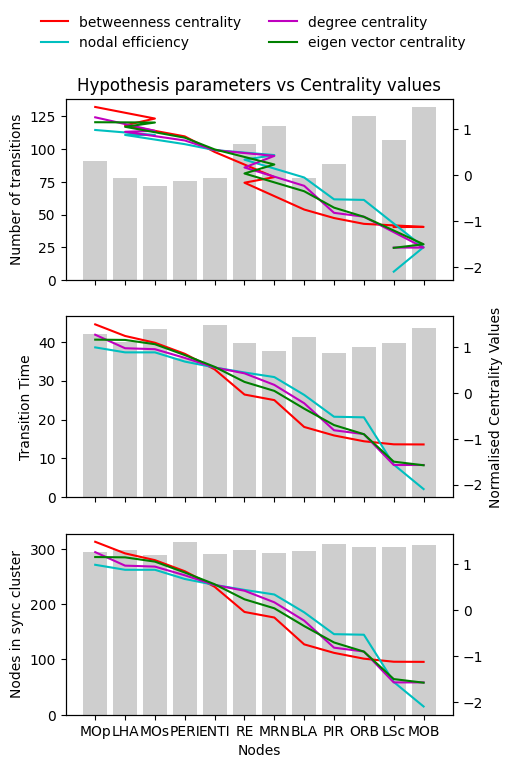

In [12]:
f, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(5, 8), sharex=True)

ax1.set_title("Hypothesis parameters vs Centrality values")
ax1.bar(df_de["NODES"], df_de["TRANS_COUNT"], color=cm.Greys(0.3))
ax1.set_ylabel("Number of transitions")
ax1_2 = ax1.twinx()
ax1_2.plot(df_de["NODES"], df_bc["BET_CENT"], "r", label="betweenness centrality")
ax1_2.plot(df_de["NODES"], df_ne["NOD_EFF"], "c", label="nodal efficiency")
ax1_2.plot(df_de["NODES"], df_de["DEG_CENT"], "m", label="degree centrality")
ax1_2.plot(df_de["NODES"], df_ee["EIG_CENT"], "g", label="eigen vector centrality")


ax2.bar(df_bc["NODES"], df_bc["TRANS_TIME"], color=cm.Greys(0.3))
ax2.set_ylabel("Transition Time")
ax2_2 = ax2.twinx()
ax2_2.plot(df_bc["NODES"], df_bc["BET_CENT"], "r", label="betweenness centrality")
ax2_2.plot(df_bc["NODES"], df_ne["NOD_EFF"], "c", label="nodal efficiency")
ax2_2.plot(df_bc["NODES"], df_de["DEG_CENT"], "m", label="degree centrality")
ax2_2.plot(df_bc["NODES"], df_ee["EIG_CENT"], "g", label="eigen vector centrality")
ax2_2.set_ylabel("Normalised Centrality Values")

ax3.bar(df_bc["NODES"], df_bc["COVERAGE"], color=cm.Greys(0.3))
ax3.set_ylabel("Nodes in sync cluster")
ax3_2 = ax3.twinx()
ax3_2.plot(df_bc["NODES"], df_bc["BET_CENT"], "r", label="betweenness centrality")
ax3_2.plot(df_bc["NODES"], df_ne["NOD_EFF"], "c", label="nodal efficiency")
ax3_2.plot(df_bc["NODES"], df_de["DEG_CENT"], "m", label="degree centrality")
ax3_2.plot(df_bc["NODES"], df_ee["EIG_CENT"], "g", label="eigen vector centrality")
ax3.set_xlabel("Nodes")

lines, labels = ax1_2.get_legend_handles_labels()
f.legend(
    lines, labels, loc="upper center", ncol=2, frameon=False, bbox_to_anchor=(0.5, 1)
)
f.show()
# plt.subplots_adjust(bottom=0.04)

### Rough plots

Text(0.5, 1.0, 'Number of Transitions vs centrality')

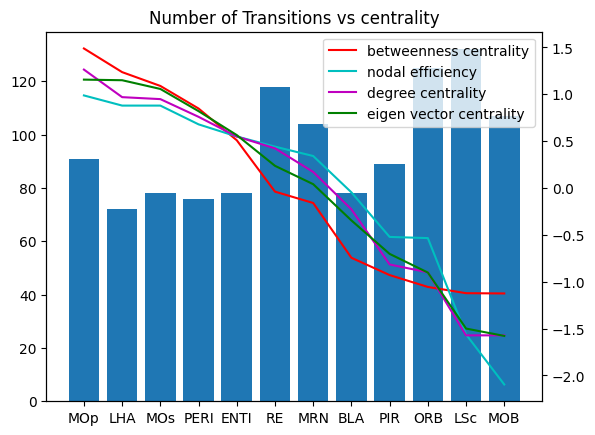

In [21]:
plt.bar(df_bc["NODES"], df_bc["TRANS_COUNT"])
plt.twinx()
plt.plot(df_bc["NODES"], df_bc["BET_CENT"], "r", label="betweenness centrality")
plt.plot(df_bc["NODES"], df_ne["NOD_EFF"], "c", label="nodal efficiency")
plt.plot(df_bc["NODES"], df_de["DEG_CENT"], "m", label="degree centrality")
plt.plot(df_bc["NODES"], df_ee["EIG_CENT"], "g", label="eigen vector centrality")
plt.legend()
plt.title("Number of Transitions vs centrality")

Text(0.5, 1.0, 'Transition time vs centrality')

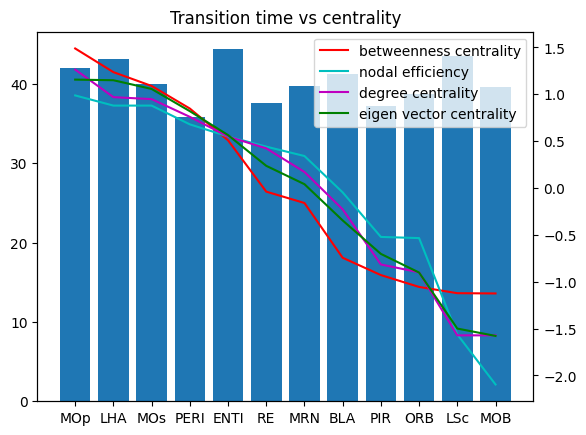

In [94]:
plt.bar(df_bc["NODES"], df_bc["TRANS_TIME"])
plt.twinx()
plt.plot(df_bc["NODES"], df_bc["BET_CENT"], "r", label="betweenness centrality")
plt.plot(df_bc["NODES"], df_ne["NOD_EFF"], "c", label="nodal efficiency")
plt.plot(df_bc["NODES"], df_de["DEG_CENT"], "m", label="degree centrality")
plt.plot(df_bc["NODES"], df_ee["EIG_CENT"], "g", label="eigen vector centrality")
plt.legend()
plt.title("Transition time vs centrality")

Text(0.5, 1.0, 'Coverage vs centrality')

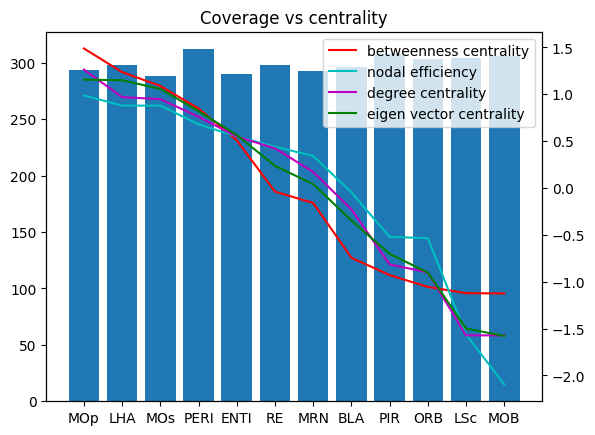

In [95]:
plt.bar(df_bc["NODES"], df_bc["COVERAGE"])
plt.twinx()
plt.plot(df_bc["NODES"], df_bc["BET_CENT"], "r", label="betweenness centrality")
plt.plot(df_bc["NODES"], df_ne["NOD_EFF"], "c", label="nodal efficiency")
plt.plot(df_bc["NODES"], df_de["DEG_CENT"], "m", label="degree centrality")
plt.plot(df_bc["NODES"], df_ee["EIG_CENT"], "g", label="eigen vector centrality")
plt.legend()
plt.title("Coverage vs centrality")

# Functional Metrics - Figure 3

- Plot on median time spent vs degree plot
- Dark grey for data nodes
- Light grey for non data nodes

#### Getting  median time spent and degree values for all nodes

In [13]:
df_nc = reader.data_read_bz2("raw/FN/nc_200.bz2")
df_itr = reader.data_read_bz2("raw/FN/itr_200.bz2")
# here G is the undirected graph
G = nx.from_numpy_array(utils.WHOLE_BRAIN_CONN)
df_r = df_nc.reset_index(drop=True)


i = 0
f = 5000
time_list = []
node_list = []
while f < df_r.shape[0]:
    l = analyse.compute_time_spent_mc(df_r.iloc[i:f, :])
    node_list.append(l)
    i = f
    f += 5000

df_time_spent = pd.DataFrame(node_list)
df_time_spent.shape

# calculate median of every column
MTS = df_time_spent.median()
med_time_spent = list(MTS)
keys = list(range(0, 426))
mts_dict = dict(zip(keys, med_time_spent))
mts_sorted = dict(sorted(mts_dict.items(), key=lambda item: item[1]))

degree = nx.degree_centrality(G)
degree_val = list(degree.values())

#### Getting MTS values for our nodes

In [14]:
mts_vals = []
nodes_half = [36, 53, 23, 113, 64, 43, 1, 215, 137, 38, 71, 149]
for i in nodes_half:
    mts_vals.append(mts_dict[i])
print(mts_vals)

[1657.0, 1582.0, 1696.0, 1577.0, 1711.0, 1716.0, 436.0, 1368.0, 961.0, 1880.0, 1560.0, 257.0]


In [15]:
len(mts_vals)

12

In [16]:
len(d)

12

## Final plot - Figure 3

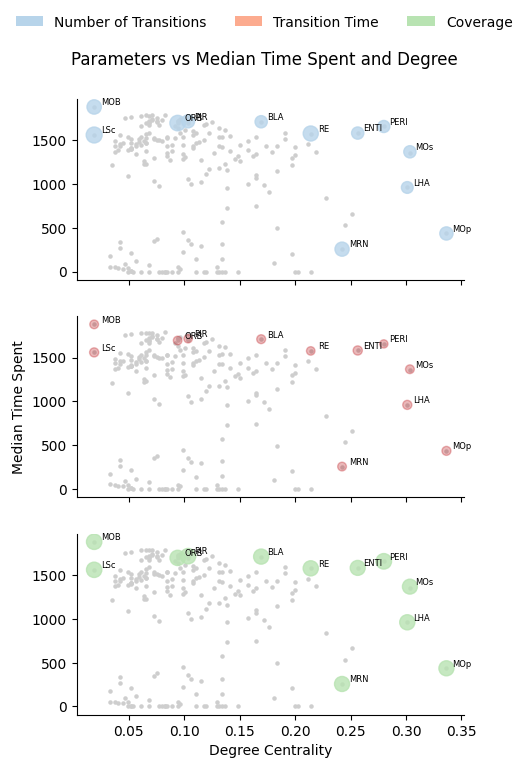

In [17]:
f, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(5, 8), sharex=True)

f.suptitle("Parameters vs Median Time Spent and Degree", x=0.5, y=0.94)
ax1.scatter(degree_val[0:213], med_time_spent[0:213], s=5, color=cm.Greys(0.3))
ax1.scatter(d, mts_vals, s=df["TRANS_COUNT"], color=cm.Blues(0.3), alpha=0.8)
ax1.spines[["right", "top"]].set_visible(False)
k = 0
for x, y, s in zip(d, mts_vals, df["TRANS_COUNT"]):

    r = np.sqrt(s)
    dx = dy = 0.05 * r / 86
    ax1.annotate(
        node_label[k],
        xy=(x, y),
        xytext=(x + dx, y + dy),
        textcoords="data",
        ha="left",
        va="bottom",
        fontsize=6,
        color="black",
    )
    k += 1

ax2.scatter(degree_val[0:213], med_time_spent[0:213], s=5, color=cm.Greys(0.3))
ax2.scatter(d, mts_vals, s=df["TRANS_TIME"], color=cm.Reds(0.8), alpha=0.3)
ax2.spines[["right", "top"]].set_visible(False)
k = 0
for x, y, s in zip(d, mts_vals, df["TRANS_COUNT"]):

    r = np.sqrt(s)
    dx = dy = 0.05 * r / 86
    ax2.annotate(
        node_label[k],
        xy=(x, y),
        xytext=(x + dx, y + dy),
        textcoords="data",
        ha="left",
        va="bottom",
        fontsize=6,
        color="black",
    )
    k += 1
ax2.set_ylabel("Median Time Spent")


ax3.scatter(degree_val[0:213], med_time_spent[0:213], s=5, color=cm.Greys(0.3))
ax3.scatter(d, mts_vals, s=df["COVERAGE"] / 2.5, color=cm.Greens(0.3), alpha=0.8)
ax3.spines[["right", "top"]].set_visible(False)
k = 0
for x, y, s in zip(d, mts_vals, df["TRANS_COUNT"]):

    r = np.sqrt(s)
    dx = dy = 0.05 * r / 86
    ax3.annotate(
        node_label[k],
        xy=(x, y),
        xytext=(x + dx, y + dy),
        textcoords="data",
        ha="left",
        va="bottom",
        fontsize=6,
        color="black",
    )
    k += 1
ax3.set_xlabel("Degree Centrality")
# Create custom legend
custom_patches = [
    Patch(facecolor=cm.Blues(0.3), label="Number of Transitions"),
    Patch(facecolor=cm.Reds(0.3), label="Transition Time"),
    Patch(facecolor=cm.Greens(0.3), label="Coverage"),
]


f.legend(
    handles=custom_patches,
    loc="upper center",
    ncol=3,
    frameon=False,
    bbox_to_anchor=(0.5, 1),
)
f.show()

Text(0.5, 1.0, 'mts_deg vs number of transitions')

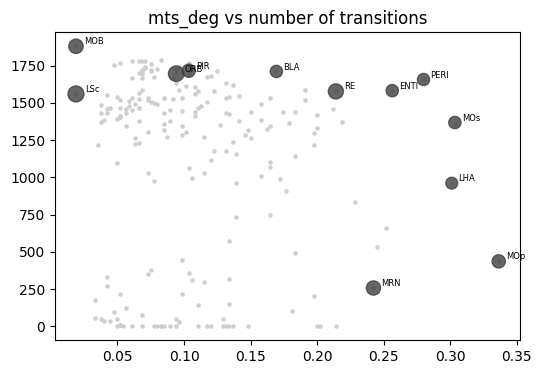

In [147]:
fig, ax = plt.subplots(figsize=(6, 4))

ax.scatter(degree_val[0:213], med_time_spent[0:213], s=5, color=cm.Greys(0.3))
ax.scatter(d, mts_vals, s=df["TRANS_COUNT"], color=cm.Greys(0.8), alpha=0.8)
k = 0
for x, y, s in zip(d, mts_vals, df["TRANS_COUNT"]):

    r = np.sqrt(s)
    dx = dy = 0.05 * r / 86
    ax.annotate(
        node_label[k],
        xy=(x, y),
        xytext=(x + dx, y + dy),
        textcoords="data",
        ha="left",
        va="bottom",
        fontsize=6,
        color="black",
    )
    k += 1
plt.title("mts_deg vs number of transitions")

Text(0.5, 1.0, 'mts_deg vs transition time')

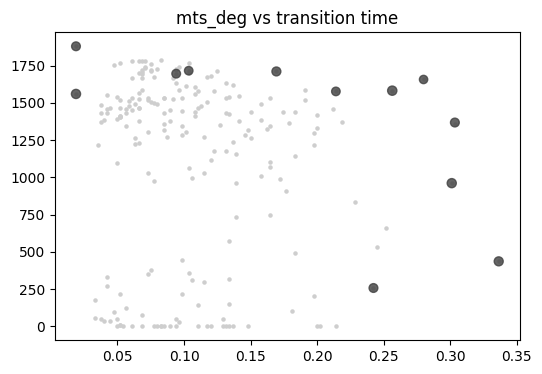

In [118]:
plt.figure(figsize=(6, 4))
plt.scatter(degree_val[0:213], med_time_spent[0:213], s=5, color=cm.Greys(0.3))
plt.scatter(d, mts_vals, s=df["TRANS_TIME"], color=cm.Greys(0.8), alpha=0.8)
plt.title("mts_deg vs transition time")

Text(0.5, 1.0, 'mts_deg vs coverage')

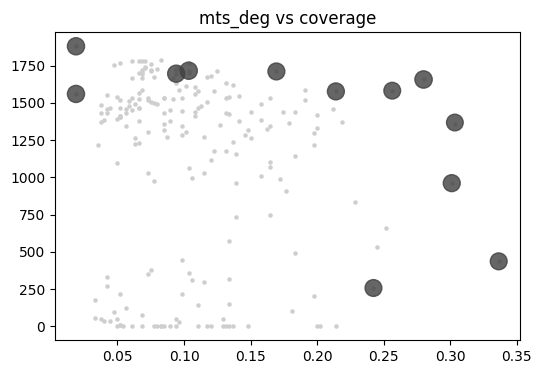

In [146]:
plt.figure(figsize=(6, 4))
plt.scatter(degree_val[0:213], med_time_spent[0:213], s=5, color=cm.Greys(0.3))
plt.scatter(d, mts_vals, s=df["COVERAGE"] / 2, color=cm.Greys(0.8), alpha=0.8)
plt.title("mts_deg vs coverage")

# Time of Entry

In [4]:
def avg_toe(df):
    i = 0
    f = 5000
    # df=df_r_fn
    toe = []
    while f < df.shape[0]:
        mc = analyse.compute_main_cluster(df.iloc[i:f, :])
        t = analyse.compute_toe(df.iloc[i:f, :], mc)
        toe.append(t)
        i = f
        f += 5000
    # can use mean or median accordingly

    col_mean = np.median(np.array(toe), axis=0)
    return col_mean

In [5]:
FN_folder = Path("../../data/raw/FN/")
ENTI_folder = Path("../../data/raw/ENTI/")
ORBI_folder = Path("../../data/raw/ORBI/")
PERI_folder = Path("../../data/raw/PERI/")
PIR_folder = Path("../../data/raw/PIR/")
RE_folder = Path("../../data/raw/RE/")
BLA_folder = Path("../../data/raw/BLA")
files = []
folders = [
    FN_folder,
    ENTI_folder,
    ORBI_folder,
    PERI_folder,
    PIR_folder,
    RE_folder,
    BLA_folder,
]
label = ["FN", "ENTI", "ORBI", "PERI", "PIR", "RE", "BLA"]
for folder in folders:
    file = glob.glob(str(folder / "nc_200.bz2"))
    files.append(file)

print(files)
toe = []
for f in files:
    df_nc = pd.read_pickle(f[0], compression="bz2")
    df_r = df_nc.reset_index(drop=True)
    mean_toe = avg_toe(df_r)
    toe.append(mean_toe)

# Sorting by communities
desired_order = list(reader.get_communities()["des_order"])
df_toe = pd.DataFrame(toe, index=label).T

# very powerful, whenever you concat any node data to community map, it automatically arranges in that order
toe_plot_data = pd.concat(
    [reader.get_communities()["comm_map"].to_frame(), df_toe], axis=1
)
toe_plot_data.columns = ["community", "FN", "ENTI", "ORBI", "PERI", "PIR", "RE", "BLA"]

[['../../data/raw/FN/nc_200.bz2'], ['../../data/raw/ENTI/nc_200.bz2'], ['../../data/raw/ORBI/nc_200.bz2'], ['../../data/raw/PERI/nc_200.bz2'], ['../../data/raw/PIR/nc_200.bz2'], ['../../data/raw/RE/nc_200.bz2'], ['../../data/raw/BLA/nc_200.bz2']]


In [6]:
toe_plot_data

,community,FN,ENTI,ORBI,PERI,PIR,RE,BLA
0,MO,2706.0,3004.0,2577.5,3198.0,3150.0,2816.0,3218.0
1,MO,3655.0,3629.0,3632.5,3687.0,3609.0,3652.0,3679.0
2,MO,3451.0,3419.0,3435.5,3457.0,3406.0,3420.0,3465.0
3,MO,3481.0,3510.0,3461.0,3512.0,3459.0,3442.0,3493.0
4,MO,3470.0,3461.0,3479.0,3499.0,3444.0,3464.0,3493.0
...,...,...,...,...,...,...,...,...
421,HIND,1172.0,1518.0,964.0,1419.0,2052.5,1535.0,1168.0
422,HIND,4999.0,4999.0,4999.0,4999.0,4999.0,4999.0,4999.0
423,HIND,4999.0,4999.0,4999.0,4999.0,4999.0,4999.0,4999.0
424,HIND,4999.0,4999.0,4999.0,4999.0,4999.0,4999.0,4999.0


In [7]:
toe_means = toe_plot_data.groupby("community")[
    ["FN", "ENTI", "ORBI", "PERI", "PIR", "RE", "BLA"]
].mean()
# print(grouped_means)
toe_means.head()

,FN,ENTI,ORBI,PERI,PIR,RE,BLA
community,,,,,,,
HIND,4286.802326,4300.511628,4305.156977,4286.267442,4306.668605,4328.581395,4311.709302
HIPP,3031.880000,2982.960000,2943.890000,2932.320000,2965.700000,2979.700000,2958.700000
HTh,3224.181818,3190.681818,3183.420455,3216.795455,3244.375000,3203.795455,3238.772727
MID,3434.757143,3398.571429,3412.828571,3405.528571,3392.385714,3460.471429,3404.657143
MO,3106.000000,3135.535714,3051.526786,3291.500000,3086.812500,3114.214286,3206.928571


In [8]:
toe_stats = toe_plot_data.groupby("community")[
    ["FN", "ENTI", "ORBI", "PERI", "PIR", "RE", "BLA"]
].agg(["min", "max", "mean", "median", "mad"])
print(toe_stats)

               FN                                             ENTI          \
              min     max         mean  median         mad     min     max   
community                                                                    
HIND       1172.0  4999.0  4286.802326  4999.0  755.848567  1408.0  4999.0   
HIPP        387.0  3547.0  3031.880000  3400.0  598.872000   407.0  3563.0   
HTh        1644.0  3515.0  3224.181818  3329.5  209.520661  1997.0  3463.0   
MID        1491.0  3774.0  3434.757143  3443.5  145.142449  1909.0  3776.0   
MO         1581.0  3662.0  3106.000000  3278.5  372.964286  1686.0  3629.0   
OLF         213.0  3335.0  2493.583333  2846.0  641.986111   186.0  4999.0   
ORB        2052.0  3518.0  3197.352941  3289.5  196.816609  2166.0  3559.0   
VIS        1511.0  3457.0  3175.800000  3298.5  259.848000  1345.0  3437.0   

                                            ...      RE                       \
                  mean  median         mad  ...     min     m

/tmp/ipykernel_3474627/4034880085.py:1: FutureWarning: The 'mad' method is deprecated and will be removed in a future version. To compute the same result, you may do `(df - df.mean()).abs().mean()`.
  toe_stats=toe_plot_data.groupby('community')[['FN','ENTI','ORBI','PERI','PIR','RE','BLA']].agg(['min','max','mean','median','mad'])
/tmp/ipykernel_3474627/4034880085.py:1: FutureWarning: The 'mad' method is deprecated and will be removed in a future version. To compute the same result, you may do `(df - df.mean()).abs().mean()`.
  toe_stats=toe_plot_data.groupby('community')[['FN','ENTI','ORBI','PERI','PIR','RE','BLA']].agg(['min','max','mean','median','mad'])
/tmp/ipykernel_3474627/4034880085.py:1: FutureWarning: The 'mad' method is deprecated and will be removed in a future version. To compute the same result, you may do `(df - df.mean()).abs().mean()`.
  toe_stats=toe_plot_data.groupby('community')[['FN','ENTI','ORBI','PERI','PIR','RE','BLA']].agg(['min','max','mean','median','mad'])
/

#### Sorting each NOI wrt median value

In [9]:
to_sort = toe_stats
toe_stats = to_sort.sort_values(("FN", "median"), ascending=True)
toe_stats = to_sort.sort_values(("ENTI", "median"), ascending=True)
toe_stats = to_sort.sort_values(("ORBI", "median"), ascending=True)
toe_stats = to_sort.sort_values(("PERI", "median"), ascending=True)
toe_stats = to_sort.sort_values(("PIR", "median"), ascending=True)
toe_stats = to_sort.sort_values(("RE", "median"), ascending=True)
toe_stats = to_sort.sort_values(("BLA", "median"), ascending=True)
print(toe_stats)

               FN                                             ENTI          \
              min     max         mean  median         mad     min     max   
community                                                                    
OLF         213.0  3335.0  2493.583333  2846.0  641.986111   186.0  4999.0   
ORB        2052.0  3518.0  3197.352941  3289.5  196.816609  2166.0  3559.0   
VIS        1511.0  3457.0  3175.800000  3298.5  259.848000  1345.0  3437.0   
MO         1581.0  3662.0  3106.000000  3278.5  372.964286  1686.0  3629.0   
HTh        1644.0  3515.0  3224.181818  3329.5  209.520661  1997.0  3463.0   
HIPP        387.0  3547.0  3031.880000  3400.0  598.872000   407.0  3563.0   
MID        1491.0  3774.0  3434.757143  3443.5  145.142449  1909.0  3776.0   
HIND       1172.0  4999.0  4286.802326  4999.0  755.848567  1408.0  4999.0   

                                            ...      RE                       \
                  mean  median         mad  ...     min     m

In [9]:
for main_col in toe_stats.columns.levels[0]:
    try:
        toe_stats[(main_col, "error_low")] = (
            toe_stats[(main_col, "mad")] - toe_stats[(main_col, "min")]
        )
        toe_stats[(main_col, "error_high")] = (
            toe_stats[(main_col, "max")] - toe_stats[(main_col, "mad")]
        )
    except KeyError:
        # In case any of the sub-columns ('min', 'mean', 'max') are missing
        continue
print(toe_stats)
toe_stats.head()

               FN                                             ENTI          \
              min     max         mean  median         mad     min     max   
community                                                                    
HIND       1172.0  4999.0  4286.802326  4999.0  755.848567  1408.0  4999.0   
HIPP        387.0  3547.0  3031.880000  3400.0  598.872000   407.0  3563.0   
HTh        1644.0  3515.0  3224.181818  3329.5  209.520661  1997.0  3463.0   
MID        1491.0  3774.0  3434.757143  3443.5  145.142449  1909.0  3776.0   
MO         1581.0  3662.0  3106.000000  3278.5  372.964286  1686.0  3629.0   
OLF         213.0  3335.0  2493.583333  2846.0  641.986111   186.0  4999.0   
ORB        2052.0  3518.0  3197.352941  3289.5  196.816609  2166.0  3559.0   
VIS        1511.0  3457.0  3175.800000  3298.5  259.848000  1345.0  3437.0   

                                            ...         ORBI               \
                  mean  median         mad  ...    error_low   e

FN                                             ENTI          \
              min     max         mean  median         mad     min     max   
community                                                                    
HIND       1172.0  4999.0  4286.802326  4999.0  755.848567  1408.0  4999.0   
HIPP        387.0  3547.0  3031.880000  3400.0  598.872000   407.0  3563.0   
HTh        1644.0  3515.0  3224.181818  3329.5  209.520661  1997.0  3463.0   
MID        1491.0  3774.0  3434.757143  3443.5  145.142449  1909.0  3776.0   
MO         1581.0  3662.0  3106.000000  3278.5  372.964286  1686.0  3629.0   

                                            ...         ORBI               \
                  mean  median         mad  ...    error_low   error_high   
community                                   ...                             
HIND       4300.511628  4934.5  739.672796  ...  -206.248648  4241.248648   
HIPP       2982.960000  3392.0  678.664000  ...   427.036000  2844.964000   
HTh        3190.681818  3311.5  239.853306  ... -1724.794421  3219.294421   
MID        3398.571429  3406.5  133.906122  ... -1297.123265  3671.623265   
MO         3135.535714  3275.5  304.096939  ...  -760.913265  3229.413265   

                  PERI                       PIR                        RE  \
             error_low   error_high    error_low   error_high    error_low   
community                                                                    
HIND       -606.404002  4229.404002  -231.017712  4257.017712  -503.968632   
HIPP        448.528000  2816.472000   372.720000  2844.780000   290.920000   
HTh       -1415.737603  3230.737603 -1454.630682  3289.130682 -1755.301653   
MID       -1849.388980  3593.388980 -1499.804490  3567.804490 -1588.190612   
MO        -1176.571429  4636.571429  -553.825893  3247.325893  -844.091837   

                                BLA               
            error_high    error_low   error_high  
community                                         
HIND       4282.968632  -430.785019  4261.785019  
HIPP       2895.080000   397.680000  2849.320000  
HTh        3255.301653 -1771.935950  3283.935950  
MID        4822.190612 -1691.389388  3673.389388  
MO         3305.091837  -784.579082  4622.579082  

[5 rows x 49 columns]

In [24]:
toe_stats[("FN", "error_low")]

community
HIND    3114.802326
HIPP    2644.880000
HTh     1580.181818
MID     1943.757143
MO      1525.000000
OLF     2280.583333
ORB     1145.352941
VIS     1664.800000
Name: (FN, error_low), dtype: float64

In [10]:
comm_labels = toe_stats.index.get_level_values("community")

In [11]:
lab_list = list(comm_labels)

NameError: name 'row' is not defined

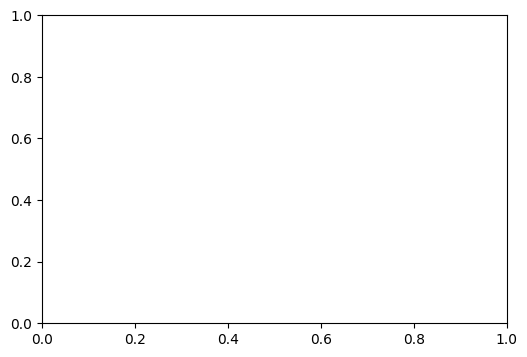

In [12]:
toe_stats[("FN", "min")]
y = toe_stats[("FN", "mean")]
x = toe_stats.index.get_level_values("community")
y_errormin = toe_stats[("FN", "min")]
y_errormax = toe_stats[("FN", "max")]
yerr = np.row_stack([y - y_errormin, y_errormax - y])
# y_error=[y_errormin,y_errormax]
# plt.errorbar(x,y,yerr=y_error
#              ,fmt='o',capsize=4, elinewidth=2.5, capthick=2.5)
colors = {
    "HIND": "red",
    "HIPP": "orange",
    "HTh": "green",
    "MID": "blue",
    "MO": "purple",
    "OLF": "brown",
    "ORB": "teal",
    "VIS": "black",
}
fig, ax = plt.subplots(figsize=(6, 4))

# x = np.arange(len(cols))
ax.errorbar(
    x,
    y,
    yerr=yerr,
    fmt="o",
    color="k",
    ecolor=colors[row["community"]],
    capsize=4,
    elinewidth=2.5,
    capthick=2.5,
)

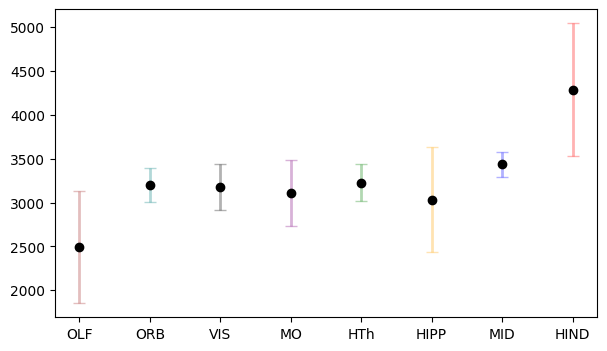

In [10]:
colors = {
    "HIND": "red",
    "HIPP": "orange",
    "HTh": "green",
    "MID": "blue",
    "MO": "purple",
    "OLF": "brown",
    "ORB": "teal",
    "VIS": "black",
}

# Make yerr as (2 x N) array: [lower, upper]
# yerr = np.row_stack([df['err_low'], df['err_high']])

fig, ax = plt.subplots(figsize=(7, 4))

# Plot each point individually
for idx, row in toe_stats["FN"].iterrows():

    # err = [[row['error_low']], [row['error_high']]]
    ax.errorbar(
        idx,
        row["mean"],
        yerr=row["mad"],
        fmt="o",
        color="k",
        ecolor=mcolors.to_rgba(colors[idx], alpha=0.3),  # <- color by community
        elinewidth=2,
        capsize=4,
    )

# Time of Entry with error bar 
- Do for others

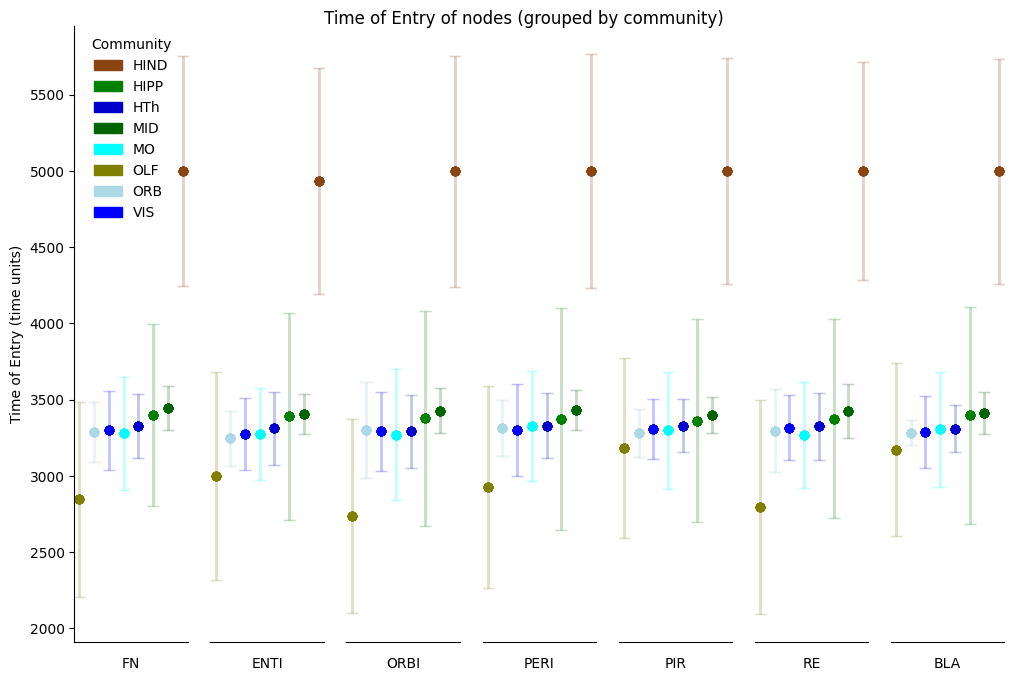

In [14]:
l = reader.get_communities()["comm_val"]
l = l.to_dict()
comm = ["MO", "VIS", "ORB", "HTh", "OLF", "HIPP", "MID", "HIND"]

node_c_avi = [
    "#00FFFF",
    "#0000FF",
    "#ADD8E6",
    "#0000CD",
    "#808000",
    "#008000",
    "#006400",
    "#8B4513",
]
colors = {
    "HIND": "#8B4513",
    "HIPP": "#008000",
    "HTh": "#0000CD",
    "MID": "#006400",
    "MO": "#00FFFF",
    "OLF": "#808000",
    "ORB": "#ADD8E6",
    "VIS": "#0000FF",
}
fig, ax = plt.subplots(1, 7, sharex=True, sharey=True, figsize=(12, 8))


node_c_nim = [
    "#FF0000",
    "#00FF00",
    "#0000FF",
    "#FFFF00",
    "#00FFFF",
    "#FF00FF",
    "#FFA500",
    "#800080",
]
col = dict(zip(comm, node_c_nim))
grouped = toe_plot_data.groupby("community")
for community, group in grouped:
    k = 0
    for idx, row in toe_stats["FN"].iterrows():

        # err = [[row['error_low']], [row['error_high']]]
        ax[0].errorbar(
            k,
            row["median"],
            yerr=row["mad"],
            fmt="o",
            color=colors[idx],
            ecolor=mcolors.to_rgba(colors[idx], alpha=0.03),  # <- color by community
            elinewidth=2,
            capsize=4,
            label=idx,
        )
        k += 1

        ax[0].set_ylabel("Time of Entry (time units)")
        # ax[0].spines[["left", "right", "top", "bottom"]].set_visible(False)
        # ax[0].set_xticks([50])
        ax[0].set_xticklabels([])
        ax[0].set_xlabel("FN")
    # ax[0].tick_params(axis="both", which="both", length=0)

    k = 0
    for idx, row in toe_stats["ENTI"].iterrows():

        # err = [[row['error_low']], [row['error_high']]]
        ax[1].errorbar(
            k,
            row["median"],
            yerr=row["mad"],
            fmt="o",
            color=colors[idx],
            ecolor=mcolors.to_rgba(colors[idx], alpha=0.03),  # <- color by community
            elinewidth=2,
            capsize=4,
        )
        k += 1

        # ax[0].spines[["left", "right", "top", "bottom"]].set_visible(False)
        # ax[0].set_xticks([50])

        # ax[1].set_xticks([50])
        ax[1].set_xticklabels([])
        ax[1].set_xlabel("ENTI")

    k = 0
    for idx, row in toe_stats["ORBI"].iterrows():

        # err = [[row['error_low']], [row['error_high']]]
        ax[2].errorbar(
            k,
            row["median"],
            yerr=row["mad"],
            fmt="o",
            color=colors[idx],
            ecolor=mcolors.to_rgba(colors[idx], alpha=0.03),  # <- color by community
            elinewidth=2,
            capsize=4,
        )
        k += 1
        ax[2].set_xticklabels([])
        ax[2].set_xlabel("ORBI")

    k = 0
    for idx, row in toe_stats["PERI"].iterrows():

        # err = [[row['error_low']], [row['error_high']]]
        ax[3].errorbar(
            k,
            row["median"],
            yerr=row["mad"],
            fmt="o",
            color=colors[idx],
            ecolor=mcolors.to_rgba(colors[idx], alpha=0.03),  # <- color by community
            elinewidth=2,
            capsize=4,
        )
        k += 1
        ax[3].set_xticklabels([])
        ax[3].set_xlabel("PERI")

    k = 0
    for idx, row in toe_stats["PIR"].iterrows():

        # err = [[row['error_low']], [row['error_high']]]
        ax[4].errorbar(
            k,
            row["median"],
            yerr=row["mad"],
            fmt="o",
            color=colors[idx],
            ecolor=mcolors.to_rgba(colors[idx], alpha=0.03),  # <- color by community
            elinewidth=2,
            capsize=4,
        )
        k += 1
        ax[4].set_xticklabels([])
        ax[4].set_xlabel("PIR")

    k = 0
    for idx, row in toe_stats["RE"].iterrows():

        # err = [[row['error_low']], [row['error_high']]]
        ax[5].errorbar(
            k,
            row["median"],
            yerr=row["mad"],
            fmt="o",
            color=colors[idx],
            ecolor=mcolors.to_rgba(colors[idx], alpha=0.03),  # <- color by community
            elinewidth=2,
            capsize=4,
        )
        k += 1
        ax[5].set_xticklabels([])
        ax[5].set_xlabel("RE")

    k = 0
    for idx, row in toe_stats["BLA"].iterrows():

        # err = [[row['error_low']], [row['error_high']]]
        ax[6].errorbar(
            k,
            row["median"],
            yerr=row["mad"],
            fmt="o",
            color=colors[idx],
            ecolor=mcolors.to_rgba(colors[idx], alpha=0.03),  # <- color by community
            elinewidth=2,
            capsize=4,
        )
        k += 1
        ax[6].set_xticklabels([])
        ax[6].set_xlabel("BLA")

import matplotlib.patches as mpatches

# Assuming your 'colors' dictionary already exists
legend_elements = [
    mpatches.Patch(color=color, label=label) for label, color in colors.items()
]

ax[0].legend(
    handles=legend_elements,
    title="Community",
    loc="upper center",  # tweak as needed
    frameon=False,
)

# Remove outlines: Remove top/right spines from each subplot and hide most of the x-axis spines
for i, a in enumerate(ax):
    a.spines["top"].set_visible(False)
    a.spines["right"].set_visible(False)

    # Hide the bottom spine for all subplots except the first one:
    if i != 0:
        a.spines["bottom"].set_visible(False)
        a.tick_params(bottom=False)  # Remove tick marks on the x-axis
        a.spines["left"].set_visible(False)
        a.tick_params(left=False)
    else:
        a.spines["bottom"].set_visible(True)
        a.tick_params(bottom=True)

    # Ensure the left spine (y-axis) is visible:
    # a.spines['left'].set_visible(True)
    a.spines["bottom"].set_visible(True)
    a.tick_params(bottom=False)


# plt.legend()
plt.suptitle("Time of Entry of nodes (grouped by community)", x=0.5, y=0.9)
plt.savefig("fig_3.png")
plt.show()

In [10]:
l1 = [1, 2, 3, 4]
l2 = [5, 6, 7, 8]
categ = ["a", "a", "b", "b"]
df_dum = pd.DataFrame({"categ": categ, "l1": l1, "l2": l2})
df_dum

,categ,l1,l2
0,a,1,5
1,a,2,6
2,b,3,7
3,b,4,8


In [ ]:
f, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(5, 8), sharex=True)